In [1]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
data = pd.read_csv('../data/log-concave-density-estimate-data.csv')['x'].to_numpy()
mle  = pd.read_csv('../data/log-concave-density-estimate-mle.csv')[['newx', 'mle']]
index1 = 500
index2 = 999

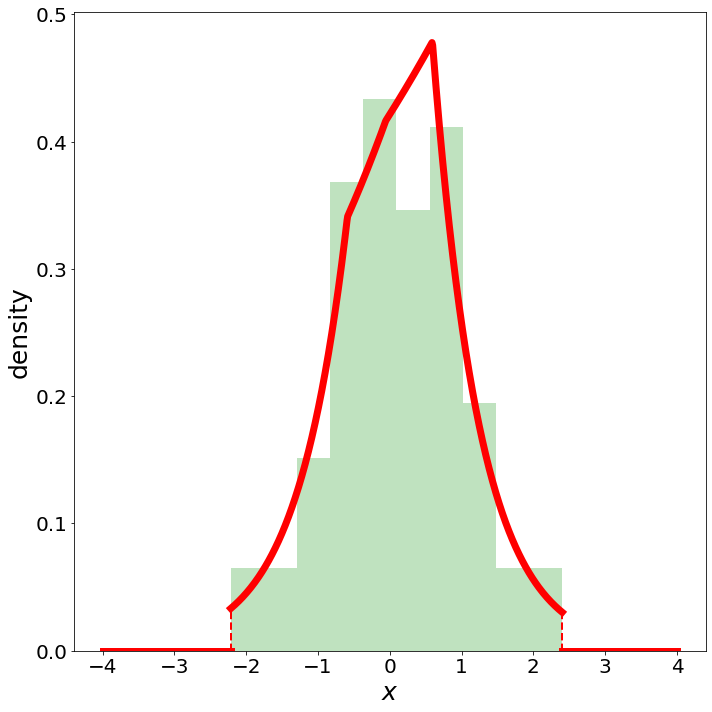

In [3]:
plt.figure(figsize = (10, 10))
label_fontsize = 25
tick_fontsize = 20
plt.hist(data, density = True, bins = 'fd', alpha = 0.3, color = 'tab:green')
plt.plot(mle.newx[index1:(index2+1)], mle.mle[index1:(index2+1)], 'r-', linewidth = 7.0)
plt.plot(mle.newx[1:index1], mle.mle[1:index1], 'r-', linewidth = 7.0)
plt.plot(mle.newx[(index2+1):], mle.mle[(index2+1):], 'r-', linewidth = 7.0)
plt.vlines(x = mle.newx[index1], ymin = 0., ymax = mle.mle[index1], 
           color = 'red', linestyle = 'dashed', linewidth = 2.)
plt.vlines(x = mle.newx[index2], ymin = 0., ymax = mle.mle[index2], 
           color = 'red', linestyle = 'dashed', linewidth = 2.)
plt.xlabel(r'$x$', fontsize = label_fontsize)
plt.ylabel('density', fontsize = label_fontsize)
plt.xticks(fontsize = tick_fontsize)
plt.yticks(fontsize = tick_fontsize)

plt.tight_layout()

# plt.savefig(f'../plots/log-concave-density-estimate-mle.pdf', 
#             bbox_inches = 'tight')

In [5]:
mle

,newx,mle
0,-4.000000,0.0
1,-3.996422,0.0
2,-3.992844,0.0
3,-3.989267,0.0
4,-3.985689,0.0
...,...,...
1495,3.987187,0.0
1496,3.990390,0.0
1497,3.993594,0.0
1498,3.996797,0.0


In [6]:
def normal_den(x, mean=0., sd=1.): 
    return np.exp(-(x - mean) ** 2 / 2. / sd ** 2) / np.sqrt(2 * np.pi)

In [7]:
true_den = normal_den(x = mle.newx, mean=0., sd=1.)

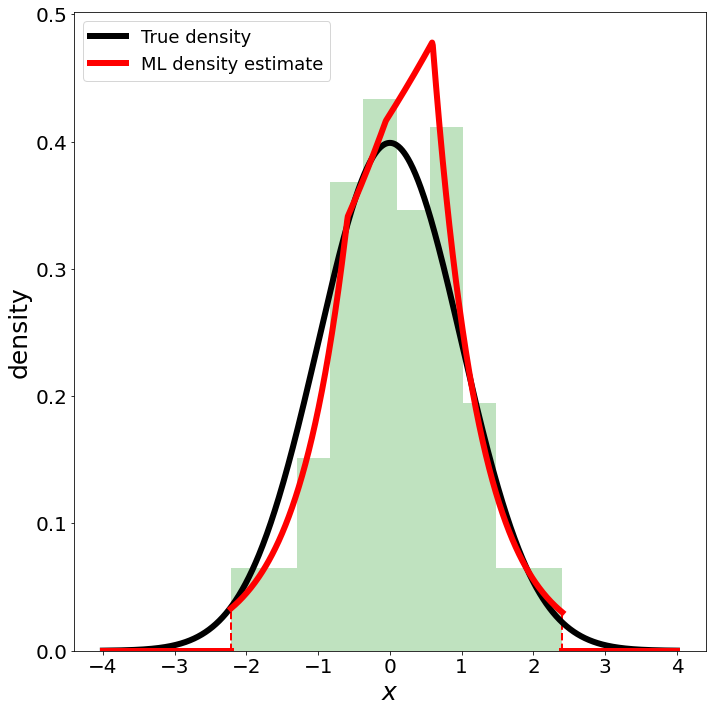

In [19]:
plt.figure(figsize = (10, 10))
label_fontsize = 25
tick_fontsize = 20
legend_fontsize = 18

linewidth = 6
plt.hist(data, density = True, bins = 'fd', alpha = 0.3, color = 'tab:green')

plt.plot(mle.newx, true_den, linewidth = linewidth, color = 'k', label = 'True density')

plt.plot(mle.newx[index1:(index2+1)], mle.mle[index1:(index2+1)], 'r-', linewidth = linewidth, 
        label = 'ML density estimate')
plt.plot(mle.newx[1:index1], mle.mle[1:index1], 'r-', linewidth = linewidth)
plt.plot(mle.newx[(index2+1):], mle.mle[(index2+1):], 'r-', linewidth = linewidth)
plt.vlines(x = mle.newx[index1], ymin = 0., ymax = mle.mle[index1], 
           color = 'red', linestyle = 'dashed', linewidth = 2.)
plt.vlines(x = mle.newx[index2], ymin = 0., ymax = mle.mle[index2], 
           color = 'red', linestyle = 'dashed', linewidth = 2.)

plt.legend(loc = 'upper left', fontsize = legend_fontsize)

plt.xlabel(r'$x$', fontsize = label_fontsize)
plt.ylabel('density', fontsize = label_fontsize)
plt.xticks(fontsize = tick_fontsize)
plt.yticks(fontsize = tick_fontsize)

plt.tight_layout()

plt.savefig(f'../plots/log-concave-density-estimate-mle-with-true.pdf', 
            bbox_inches = 'tight')